# Modelo de Regresión Simple

En esta práctica se establece el modelo de regresión simple utilizando matrices como en scikitlearn

In [1]:
# Tratamiento de datos
import pandas as pd
import numpy as np

#Graficos
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

#Procesado y modelado
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
import statsmodels as sms


# configuración de matplotlib
plt.rcParams['image.cmap']="bwr"
plt.rcParams['figure.dpi']="100"
plt.rcParams['savefig.bbox']="tight"
style.use('ggplot') or plt.style.use('ggplot')

# configuración de warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
data = pd.read_csv('Advertising.csv')

Saving Advertising.csv to Advertising.csv


# Lectura de datos

In [3]:
#data = pd.read_csv("D:\OneDrive - Benemérita Universidad Autónoma de Puebla\Otoño2024\Analisis de datos\Practicas\Datasets\Advertising.csv")
# Cargar datos
#data = pd.read_csv('/content/drive/MyDrive/ciencicias de datos/modulo 4/Tareas/clase 1 /Advertising.csv')

# Análisis Exploratorio descriptivo

```
# Tiene formato de código
```



In [4]:
data.isna().sum() # Verificando na's

,0
TV,0
radio,0
newspaper,0
sales,0


In [5]:
data.describe()


,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [6]:
data.columns

Index(['TV', 'radio', 'newspaper', 'sales'], dtype='object')

In [7]:
#data = data.drop("Unnamed: 0", axis=1)

In [8]:
data.columns

Index(['TV', 'radio', 'newspaper', 'sales'], dtype='object')

In [9]:
data.corr()

,TV,radio,newspaper,sales
TV,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
newspaper,0.056648,0.354104,1.000000,0.228299
sales,0.782224,0.576223,0.228299,1.000000


<Axes: >

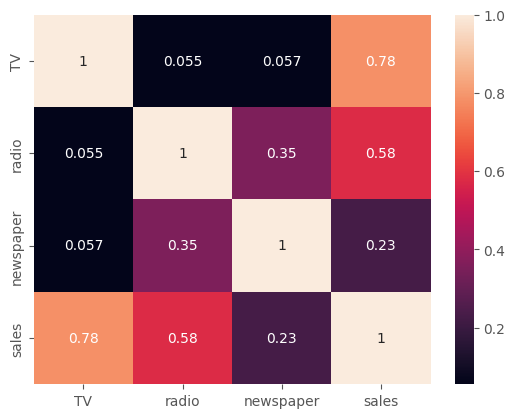

In [10]:
sns.heatmap(data.corr(), annot= True)

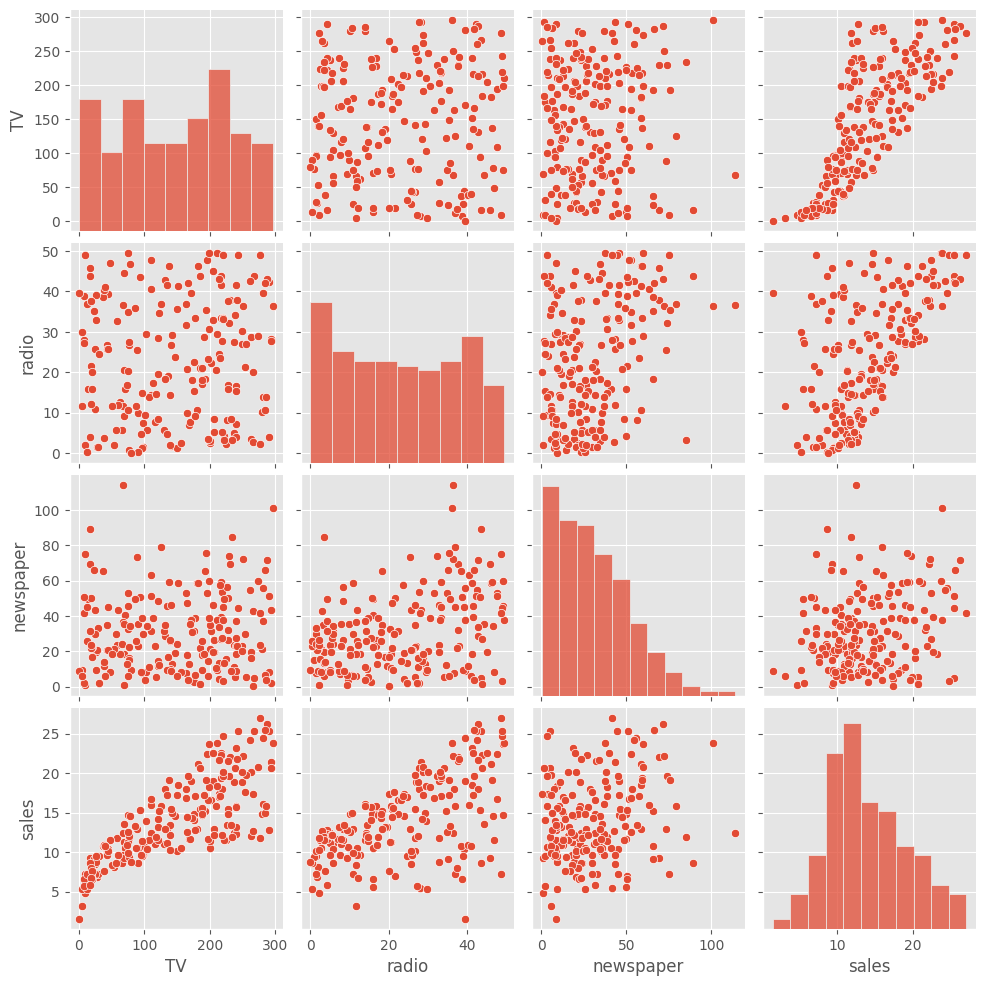

In [11]:
sns.pairplot(data)

# Ajuste del Modelo usando Scikit-learn

In [12]:
X = data[['radio']]
y = data[['sales']]
X_train, X_test, y_train, y_test = train_test_split(
                                        X.values.reshape(-1,1),
                                        y.values.reshape(-1,1),
                                        train_size = 0.8,
                                        random_state =123,
                                        shuffle = True
)
#Reshape your data either using array.reshape(-1, 1) if your data has a single feature
#or array.reshape(1, -1) if it contains a single sample.

# para mas información vea help(train_test_split)

In [13]:
X_test.shape

(40, 1)

## Ajuste del Modelo utilizando matrices como en scikitlearn

In [14]:
X_train = sm.add_constant(X_train, prepend=True)
modelo = sm.OLS(y_train, X_train)
modelo = modelo.fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.303
Model:                            OLS   Adj. R-squared:                  0.299
Method:                 Least Squares   F-statistic:                     68.82
Date:                Sat, 13 Jun 2026   Prob (F-statistic):           4.46e-14
Time:                        20:13:52   Log-Likelihood:                -459.02
No. Observations:                 160   AIC:                             922.0
Df Residuals:                     158   BIC:                             928.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.7232      0.627     15.515      0.0

In [15]:
# Intervalos de confianza para los coeficientes del modelo
# ==============================================================================
modelo.conf_int(alpha=0.05)

array([[ 8.48542762, 10.960918  ],
       [ 0.14375173,  0.23358737]])

In [16]:
predicciones = modelo.get_prediction(X_train).summary_frame(alpha=0.05)
predicciones.head(4)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,12.100409,0.415721,11.279323,12.921496,3.587835,20.612983
1,12.345680,0.399351,11.556924,13.134435,3.836163,20.855196
2,18.552908,0.635427,17.297880,19.807935,9.987580,27.118235
3,13.496564,0.346730,12.811739,14.181388,4.996051,21.997077


In [17]:
# Predicciones con intervalo de confianza del 95%
# ==============================================================================
predicciones = modelo.get_prediction(X_train).summary_frame(alpha=0.05)
predicciones['x'] = X_train[:, 1]
predicciones['y'] = y_train
predicciones = predicciones.sort_values('x')


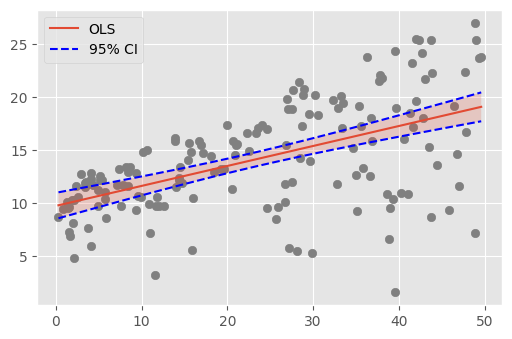

In [18]:
# Gráfico del modelo
# ==============================================================================
fig, ax = plt.subplots(figsize=(6, 3.84))
ax.scatter(predicciones['x'], predicciones['y'], marker='o', color = "gray")
ax.plot(predicciones['x'], predicciones["mean"], linestyle='-', label="OLS")
ax.plot(predicciones['x'], predicciones["mean_ci_lower"], linestyle='--', color='blue', label="95% CI")
ax.plot(predicciones['x'], predicciones["mean_ci_upper"], linestyle='--', color='blue')
ax.fill_between(predicciones['x'], predicciones["mean_ci_lower"], predicciones["mean_ci_upper"], alpha=0.2)
ax.legend();

# Evaluación del modelo

Realiza la evaluación del modelo

Ahora replica la práctica anterior para generar dos modelos.
* Modelo 2
    y: Sales
    x: newspaper

* Modelo 3
    y: Sales
    x: Tv

Realiza el análisis, comprobación de suúestos y compara el desempeño de los tres modelos, finalmente representa mediante una tabla comparativa la información relevante de lso tres modelos.

modelo sale vs newpapar


In [19]:
X = data[['newspaper']]
y = data[['sales']]
X_train, X_test, y_train, y_test = train_test_split(
                                        X.values.reshape(-1,1),
                                        y.values.reshape(-1,1),
                                        train_size = 0.8,
                                        random_state =123,
                                        shuffle = True
)
#Reshape your data either using array.reshape(-1, 1) if your data has a single feature
#or array.reshape(1, -1) if it contains a single sample.

# para mas información vea help(train_test_split)

In [20]:
X_train = sm.add_constant(X_train, prepend=True)
modelo = sm.OLS(y_train, X_train)
modelo = modelo.fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     8.663
Date:                Sat, 13 Jun 2026   Prob (F-statistic):            0.00374
Time:                        20:13:52   Log-Likelihood:                -483.68
No. Observations:                 160   AIC:                             971.4
Df Residuals:                     158   BIC:                             977.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.5134      0.667     18.752      0.0

In [21]:
predicciones = modelo.get_prediction(X_train).summary_frame(alpha=0.05)
predicciones.head(4)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,13.473409,0.448484,12.587612,14.359206,3.549264,23.397554
1,14.454420,0.414064,13.636605,15.272235,4.536111,24.372728
2,14.323269,0.403177,13.526956,15.119581,4.406710,24.239827
3,12.529121,0.663006,11.219624,13.838619,2.558223,22.500019


In [22]:
# Predicciones con intervalo de confianza del 95%
# ==============================================================================
predicciones = modelo.get_prediction(X_train).summary_frame(alpha=0.05)
predicciones['x'] = X_train[:, 1]
predicciones['y'] = y_train
predicciones = predicciones.sort_values('x')

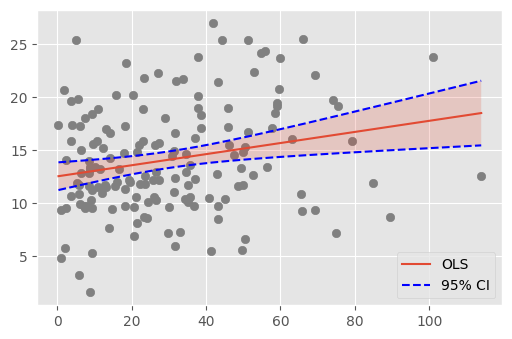

In [23]:
fig, ax = plt.subplots(figsize=(6, 3.84))
ax.scatter(predicciones['x'], predicciones['y'], marker='o', color = "gray")
ax.plot(predicciones['x'], predicciones["mean"], linestyle='-', label="OLS")
ax.plot(predicciones['x'], predicciones["mean_ci_lower"], linestyle='--', color='blue', label="95% CI")
ax.plot(predicciones['x'], predicciones["mean_ci_upper"], linestyle='--', color='blue')
ax.fill_between(predicciones['x'], predicciones["mean_ci_lower"], predicciones["mean_ci_upper"], alpha=0.2)
ax.legend();

In [24]:
X = data[['TV']]
y = data[['sales']]
X_train, X_test, y_train, y_test = train_test_split(
                                        X.values.reshape(-1,1),
                                        y.values.reshape(-1,1),
                                        train_size = 0.8,
                                        random_state =123,
                                        shuffle = True
)
#Reshape your data either using array.reshape(-1, 1) if your data has a single feature
#or array.reshape(1, -1) if it contains a single sample.

# para mas información vea help(train_test_split)

In [25]:
X_train = sm.add_constant(X_train, prepend=True)
modelo = sm.OLS(y_train, X_train)
modelo = modelo.fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.592
Model:                            OLS   Adj. R-squared:                  0.589
Method:                 Least Squares   F-statistic:                     229.2
Date:                Sat, 13 Jun 2026   Prob (F-statistic):           1.44e-32
Time:                        20:13:53   Log-Likelihood:                -416.24
No. Observations:                 160   AIC:                             836.5
Df Residuals:                     158   BIC:                             842.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.1815      0.525     13.673      0.0

In [26]:
# Predicciones con intervalo de confianza del 95%
# ==============================================================================
predicciones = modelo.get_prediction(X_train).summary_frame(alpha=0.05)
predicciones['x'] = X_train[:, 1]
predicciones['y'] = y_train
predicciones = predicciones.sort_values('x')

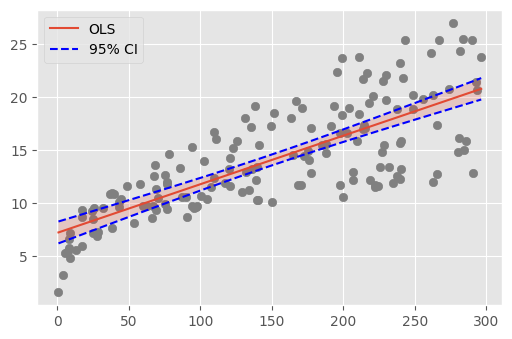

In [27]:
fig, ax = plt.subplots(figsize=(6, 3.84))
ax.scatter(predicciones['x'], predicciones['y'], marker='o', color = "gray")
ax.plot(predicciones['x'], predicciones["mean"], linestyle='-', label="OLS")
ax.plot(predicciones['x'], predicciones["mean_ci_lower"], linestyle='--', color='blue', label="95% CI")
ax.plot(predicciones['x'], predicciones["mean_ci_upper"], linestyle='--', color='blue')
ax.fill_between(predicciones['x'], predicciones["mean_ci_lower"], predicciones["mean_ci_upper"], alpha=0.2)
ax.legend();